In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import Enum
from dataclasses import dataclass
import math
from tqdm import tqdm
import sys, inspect

from tiles import *
from utils import *
import solver as solver_import

In [2]:
def plot_schedule(schedule):
    methods = inspect.getmembers(schedule, inspect.ismethod)
    methods = [(i,j) for i,j in methods if not i.startswith('_')]

    com_ax = plt.subplot()
    com_ax.set_title('Combined')

    fig, ax = plt.subplots(1, len(methods), figsize=(3.5*len(methods), 3))

    for i, (m_name, m_func) in enumerate(methods):
        # print(i, m_name,m_func)
        g = list(map(m_func, np.arange(0,schedule.max_iter))) 
        ax[i].plot(g)
        ax[i].set_title(f'{m_name} max:{max(g):.3f} min:{min(g):.3f}')

        com_ax.plot(g)
    plt.plot()

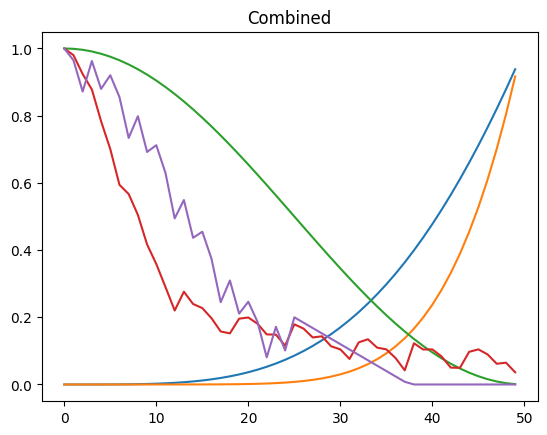

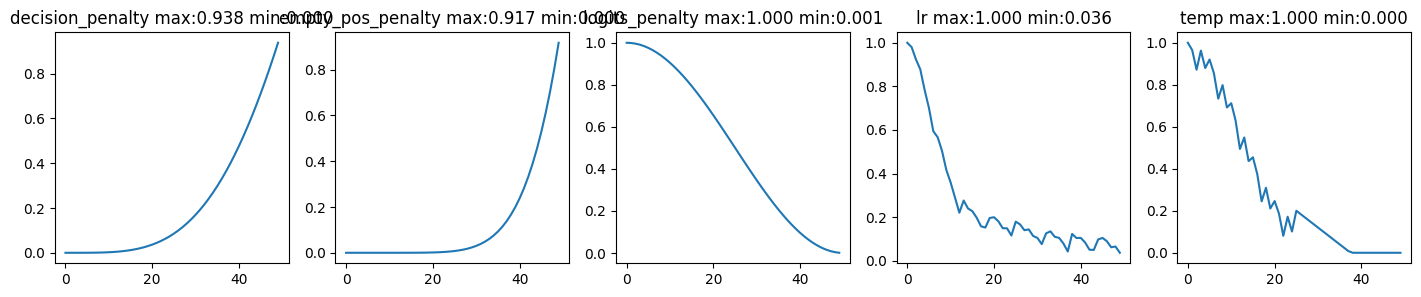

In [3]:
class Schedule:
    def __init__(self, max_iter):
        self.max_iter = max_iter
    def lr(self,x):
        x /= self.max_iter
        return ( np.cos(x*2*np.pi/4)**32 * 5 + np.cos(x*2*np.pi/4)**2 + np.cos(x*2*np.pi*5 % (np.pi/2))/5 + np.cos(x*2*np.pi*2 % (np.pi/2))/2 ) /6.7

    def temp(self,x):
        x /= self.max_iter
        if x<0.5:
            return np.maximum( np.cos(x*2*np.pi/2)**2 + np.cos(x*2*np.pi*5 % (np.pi/2))/5 , 0.001) / 1.2
        else:
            return max(0.2*(1-(x-0.5)*4),0)
    def logits_penalty(self,x):
        x /= self.max_iter
        return np.cos(x*np.pi/2)**2
    
    def decision_penalty(self,x):
        x /= self.max_iter

        x /=2
        return np.cos(x*np.pi/2 + 1/2*np.pi)**4 *4
    def empty_pos_penalty(self,x):
        x /= self.max_iter

        x /=2
        return np.cos(x*np.pi/2 + 1/2*np.pi)**8 *4 / 0.24

schedule = Schedule(50)
plot_schedule(schedule)

In [48]:
BOX_SIZE = 30
INPUT_POS = (0,3)
OUT_POS = (23, 29)
NEG_INF = -500.0

In [49]:
import importlib
importlib.reload(solver_import) # Fast reaload

sim = solver_import.FactorioSim(BOX_SIZE, DEFAULT_TILE_DATA)

In [50]:
torch.autograd.set_detect_anomaly(False, check_nan=False)

In [51]:
sns.set_context("notebook", font_scale=0.7)

In [52]:
def plot_grads(logits, losses:dict):
    fig, ax = plt.subplots(1,5,figsize=(3.2*5, 3*1))

    grads = {}
    for name,loss in losses.items():
        grads[name] = torch.autograd.grad(loss, logits, 
                                            retain_graph=True, allow_unused=True)[0][...,1::].sum(-1).detach().cpu()
    vmin = np.min(list(grads.values()))
    vmax = np.max(list(grads.values()))

    
    for i,(name,grad) in enumerate(grads.items()):
        sns.heatmap(grad,ax=ax[i],vmin=vmin,vmax=vmax,cbar=False).set_title(f'Grad/{name}')
    plt.show()

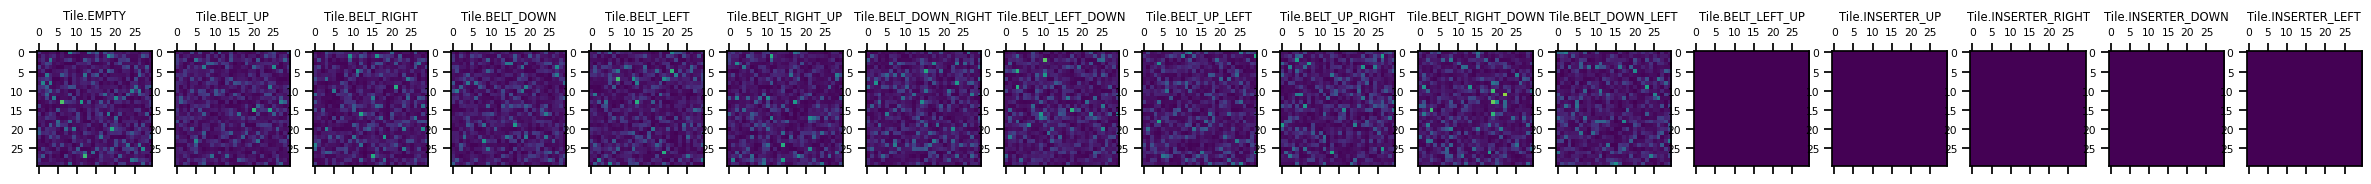

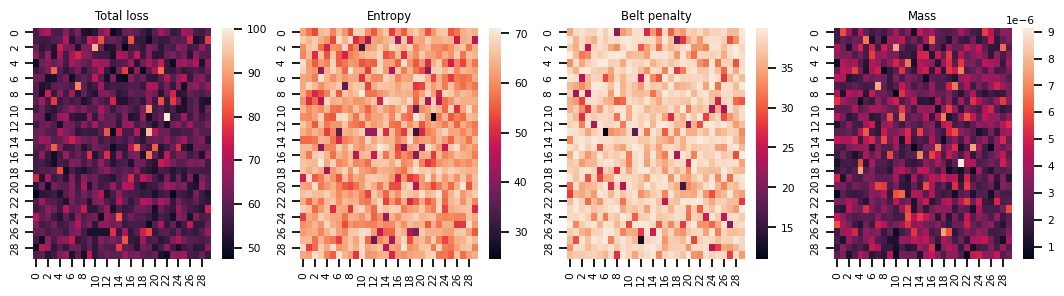

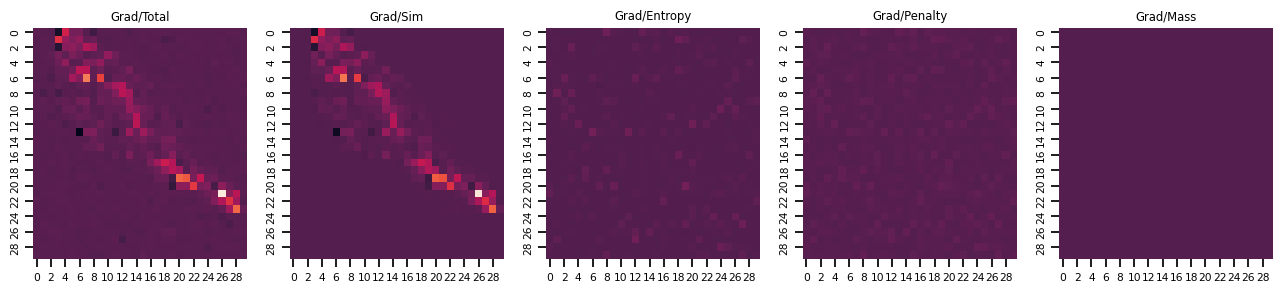

0.0% Loss comb:60.290, Path loss:85.100, Belt penalty:36.48, Mass: 0.00, Entropy:61.29
2.0% Loss comb:39.543, Path loss:63.758, Belt penalty:36.06, Mass: 0.00, Entropy:60.33
3.9% Loss comb:22.361, Path loss:46.700, Belt penalty:35.05, Mass: 0.00, Entropy:59.63
5.9% Loss comb:16.771, Path loss:38.458, Belt penalty:33.89, Mass: 0.00, Entropy:56.07
7.8% Loss comb:9.903, Path loss:31.897, Belt penalty:32.33, Mass: 0.00, Entropy:55.19
9.8% Loss comb:2.546, Path loss:23.011, Belt penalty:31.23, Mass: 0.00, Entropy:53.00
11.8% Loss comb:1.741, Path loss:22.174, Belt penalty:30.07, Mass: 0.00, Entropy:52.34
13.7% Loss comb:-5.926, Path loss:14.923, Belt penalty:28.03, Mass: 0.00, Entropy:51.32
15.7% Loss comb:-10.802, Path loss:8.631, Belt penalty:27.62, Mass: 0.00, Entropy:50.15
17.6% Loss comb:-13.577, Path loss:6.395, Belt penalty:26.92, Mass: 0.00, Entropy:50.84


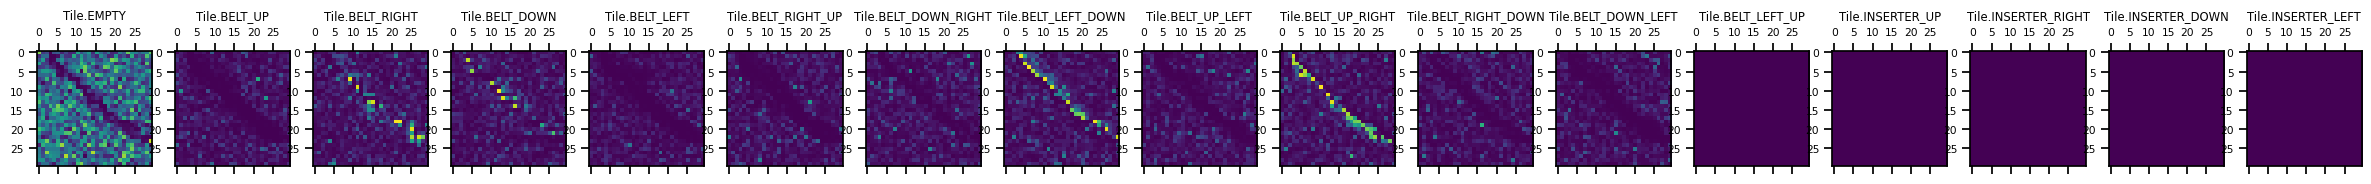

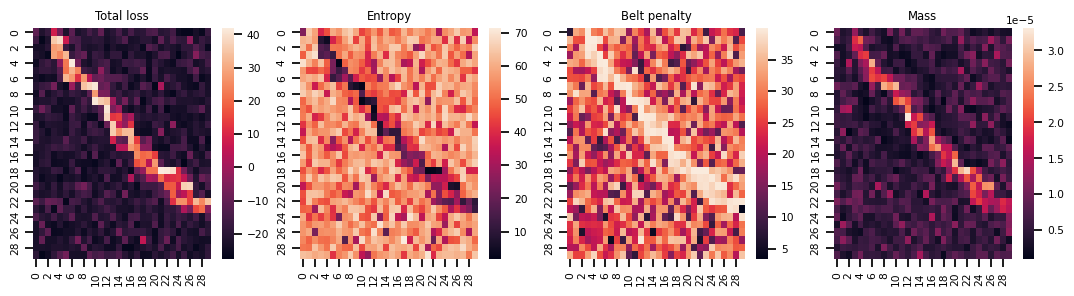

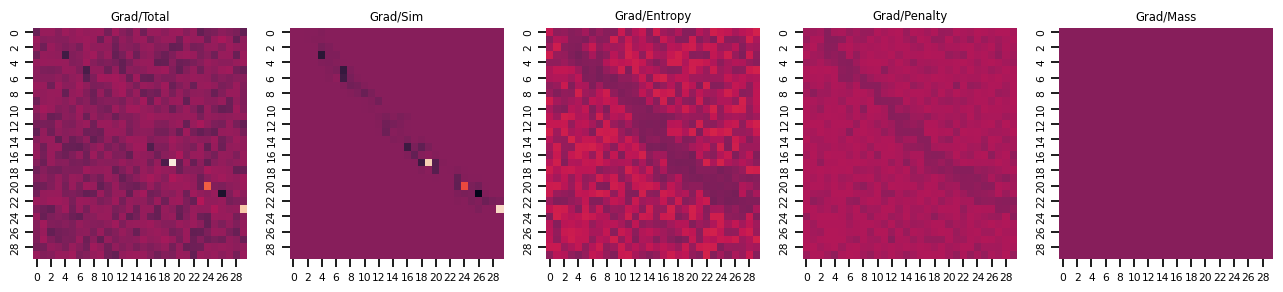

19.6% Loss comb:-15.474, Path loss:3.439, Belt penalty:26.88, Mass: 0.00, Entropy:50.63
21.6% Loss comb:-17.872, Path loss:1.350, Belt penalty:26.94, Mass: 0.00, Entropy:52.14
23.5% Loss comb:-18.686, Path loss:0.974, Belt penalty:26.22, Mass: 0.00, Entropy:53.07
25.5% Loss comb:-17.701, Path loss:0.655, Belt penalty:26.38, Mass: 0.00, Entropy:53.12
27.5% Loss comb:-18.148, Path loss:0.464, Belt penalty:26.34, Mass: 0.00, Entropy:54.91
29.4% Loss comb:-17.174, Path loss:0.292, Belt penalty:26.47, Mass: 0.00, Entropy:55.34
31.4% Loss comb:-16.526, Path loss:0.295, Belt penalty:26.18, Mass: 0.00, Entropy:56.00
33.3% Loss comb:-16.112, Path loss:0.239, Belt penalty:25.54, Mass: 0.00, Entropy:56.55
35.3% Loss comb:-14.490, Path loss:0.228, Belt penalty:25.56, Mass: 0.00, Entropy:56.50
37.3% Loss comb:-13.553, Path loss:0.213, Belt penalty:24.83, Mass: 0.00, Entropy:56.42


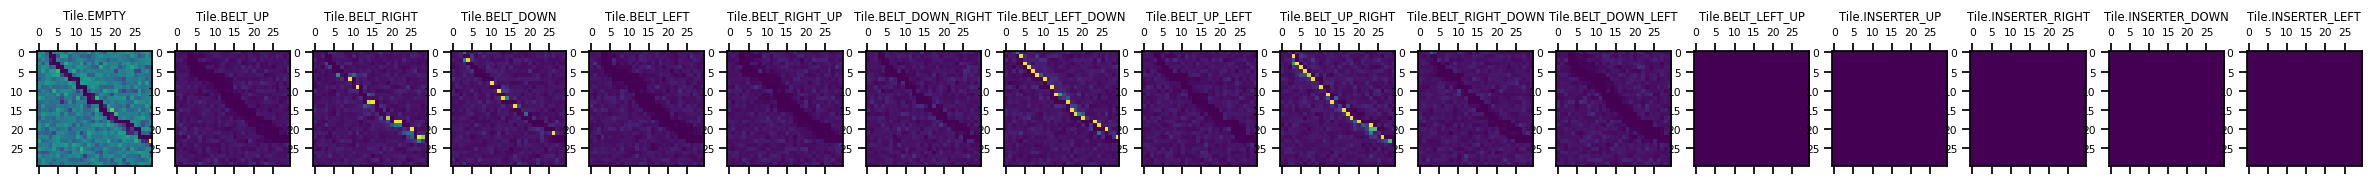

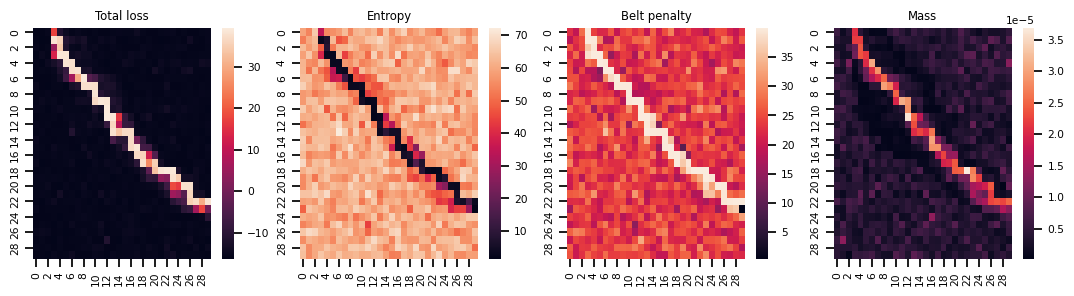

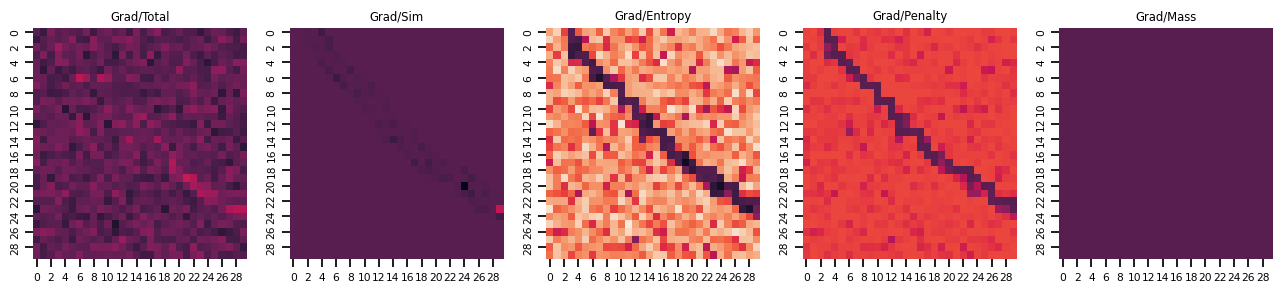

39.2% Loss comb:-11.981, Path loss:0.206, Belt penalty:24.50, Mass: 0.00, Entropy:56.05
41.2% Loss comb:-10.643, Path loss:0.191, Belt penalty:23.71, Mass: 0.00, Entropy:55.32
43.1% Loss comb:-9.310, Path loss:0.190, Belt penalty:22.93, Mass: 0.00, Entropy:54.63
45.1% Loss comb:-7.647, Path loss:0.212, Belt penalty:22.15, Mass: 0.00, Entropy:53.34
47.1% Loss comb:-6.283, Path loss:0.190, Belt penalty:20.83, Mass: 0.00, Entropy:51.37
49.0% Loss comb:-4.696, Path loss:0.194, Belt penalty:19.69, Mass: 0.00, Entropy:49.16
51.0% Loss comb:-3.395, Path loss:0.197, Belt penalty:18.22, Mass: 0.00, Entropy:46.54
52.9% Loss comb:-2.166, Path loss:0.190, Belt penalty:16.60, Mass: 0.00, Entropy:43.33
54.9% Loss comb:-1.060, Path loss:0.173, Belt penalty:14.91, Mass: 0.00, Entropy:39.74
56.9% Loss comb:-0.122, Path loss:0.156, Belt penalty:13.13, Mass: 0.00, Entropy:35.70


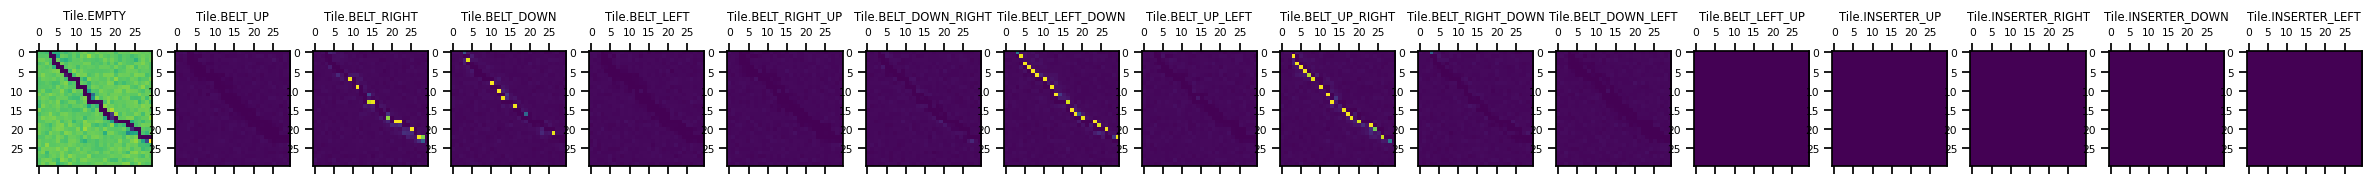

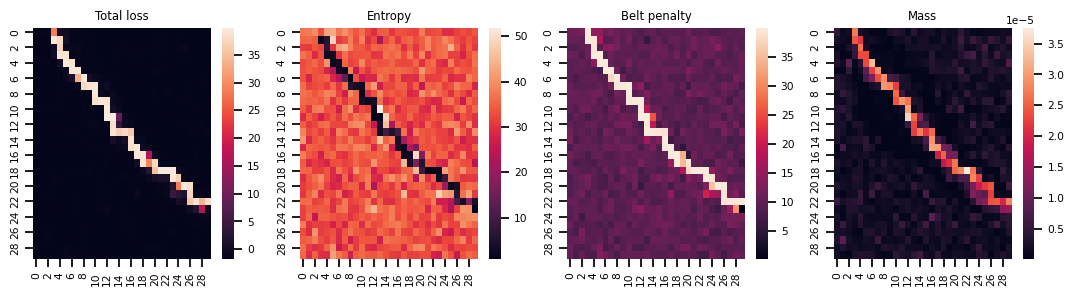

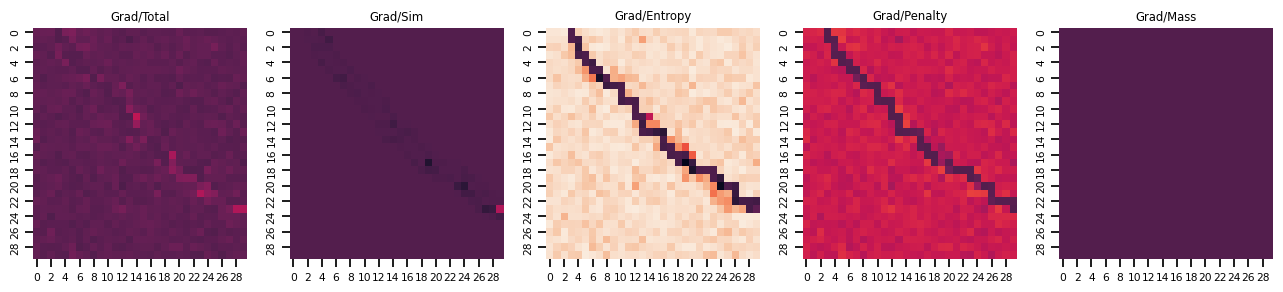

58.8% Loss comb:0.698, Path loss:0.162, Belt penalty:11.54, Mass: 0.00, Entropy:31.86
60.8% Loss comb:1.353, Path loss:0.158, Belt penalty:9.94, Mass: 0.00, Entropy:27.69
62.7% Loss comb:1.861, Path loss:0.154, Belt penalty:8.50, Mass: 0.00, Entropy:23.66
64.7% Loss comb:2.221, Path loss:0.153, Belt penalty:7.18, Mass: 0.00, Entropy:19.72
66.7% Loss comb:2.462, Path loss:0.143, Belt penalty:6.07, Mass: 0.00, Entropy:16.16
68.6% Loss comb:2.608, Path loss:0.141, Belt penalty:5.17, Mass: 0.00, Entropy:13.09
70.6% Loss comb:2.685, Path loss:0.129, Belt penalty:4.47, Mass: 0.00, Entropy:10.57
72.5% Loss comb:2.713, Path loss:0.122, Belt penalty:3.93, Mass: 0.00, Entropy:8.51
74.5% Loss comb:2.709, Path loss:0.115, Belt penalty:3.53, Mass: 0.00, Entropy:6.88
76.5% Loss comb:2.686, Path loss:0.109, Belt penalty:3.22, Mass: 0.00, Entropy:5.60


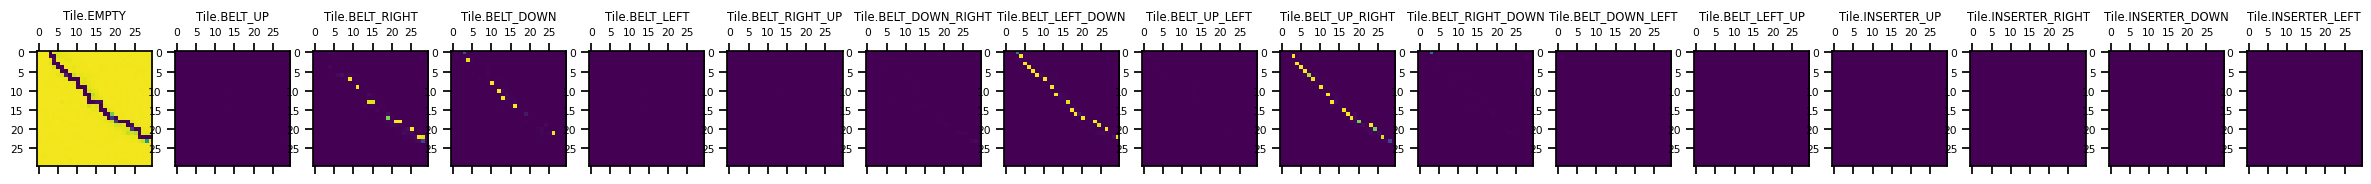

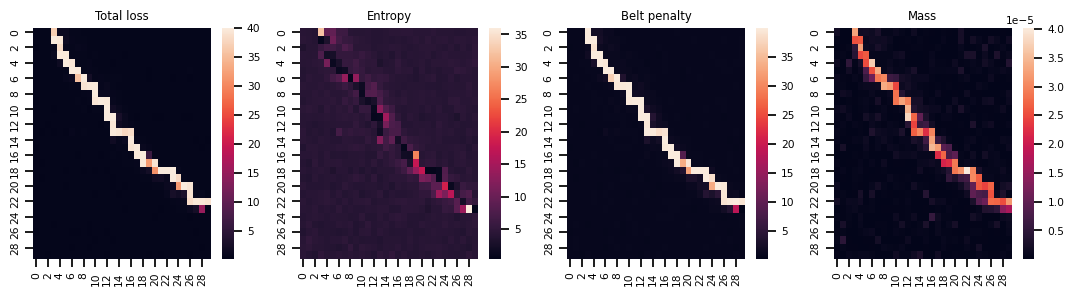

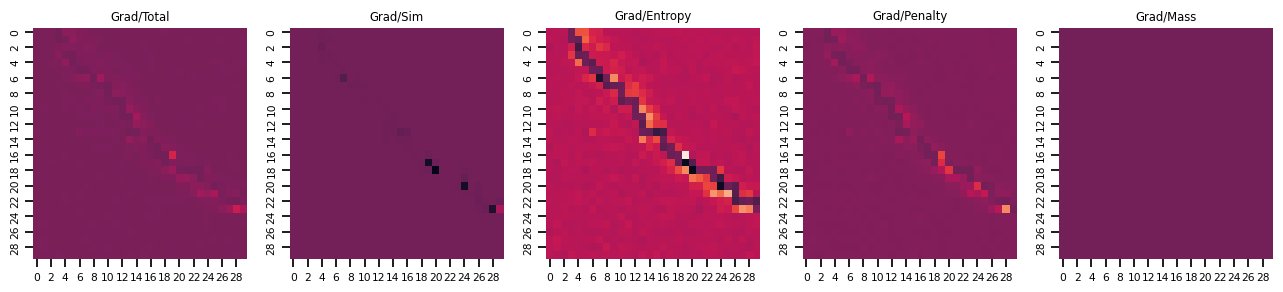

78.4% Loss comb:2.653, Path loss:0.103, Belt penalty:2.99, Mass: 0.00, Entropy:4.60
80.4% Loss comb:2.616, Path loss:0.096, Belt penalty:2.82, Mass: 0.00, Entropy:3.82
82.4% Loss comb:2.578, Path loss:0.090, Belt penalty:2.69, Mass: 0.00, Entropy:3.21
84.3% Loss comb:2.540, Path loss:0.085, Belt penalty:2.59, Mass: 0.00, Entropy:2.72
86.3% Loss comb:2.505, Path loss:0.080, Belt penalty:2.51, Mass: 0.00, Entropy:2.34
88.2% Loss comb:2.471, Path loss:0.075, Belt penalty:2.45, Mass: 0.00, Entropy:2.03
90.2% Loss comb:2.439, Path loss:0.071, Belt penalty:2.40, Mass: 0.00, Entropy:1.79
92.2% Loss comb:2.410, Path loss:0.067, Belt penalty:2.36, Mass: 0.00, Entropy:1.58
94.1% Loss comb:2.383, Path loss:0.063, Belt penalty:2.32, Mass: 0.00, Entropy:1.42
96.1% Loss comb:2.357, Path loss:0.060, Belt penalty:2.30, Mass: 0.00, Entropy:1.28


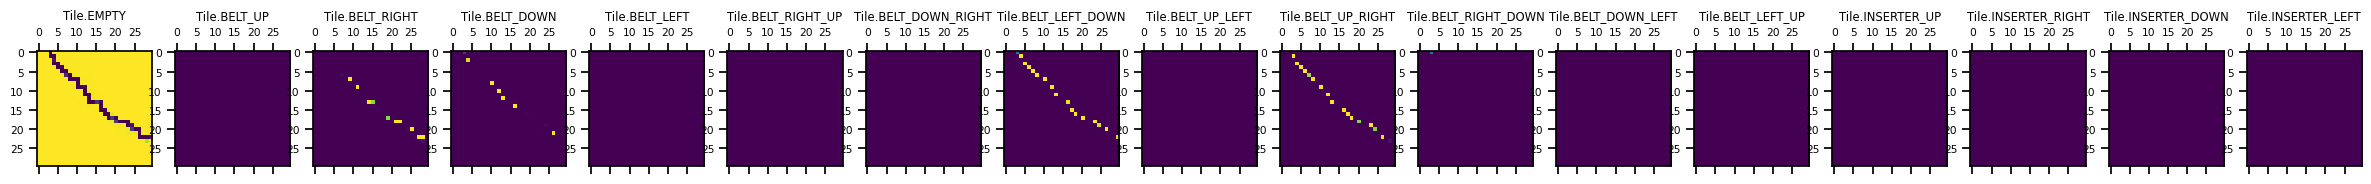

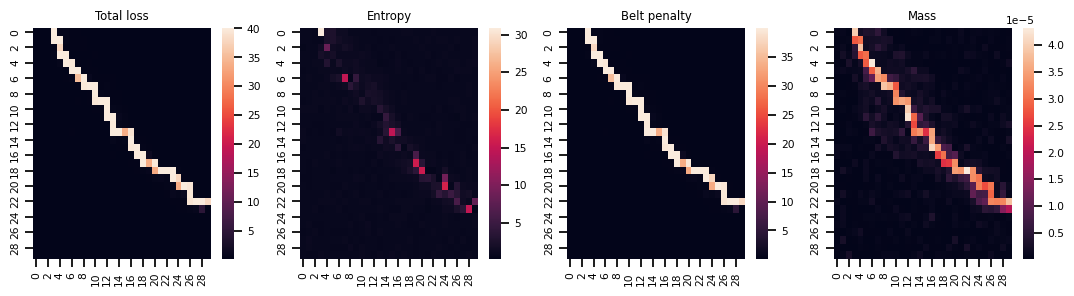

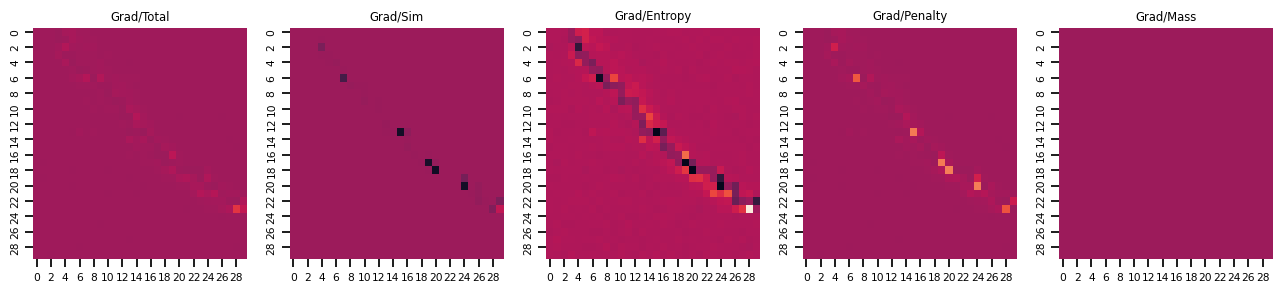

98.0% Loss comb:2.334, Path loss:0.057, Belt penalty:2.28, Mass: 0.00, Entropy:1.16


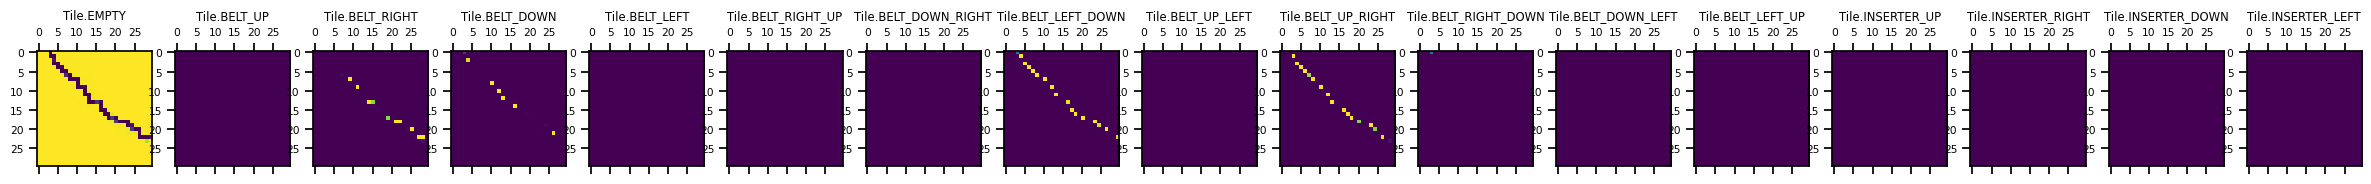

In [53]:
logits = torch.full((BOX_SIZE,BOX_SIZE,len(Tile)), NEG_INF)
active_tiles = list(range(0,12+1))

logits[:,:,active_tiles] = 5 * torch.randn(BOX_SIZE,BOX_SIZE,len(active_tiles))
logits.requires_grad_()

add_tensor = torch.zeros(BOX_SIZE,BOX_SIZE)
add_tensor[INPUT_POS[0], INPUT_POS[1]] = 100

MAX_ITER = 51
START_TEMP = 100

opt = torch.optim.Adam([logits],lr=25,betas=[0.5,0.9])
for iter in range(MAX_ITER):
    # for g in opt.param_groups:
    #     g['lr'] = 100 * schedule.lr(iter)

    logits_noise = logits + 50 * schedule.temp(iter) * torch.randn_like(logits)
    with torch.no_grad():
        logits_noise[:, :, 12::] = -25000
    solve_log = torch.nn.functional.log_softmax(logits_noise/50,dim=-1)

    # Solve: (-inf,0)
    # logits_noise: (0,inf)

    items_log = sim.eval(solve_log,add_tensor, max_iter=BOX_SIZE*1.8)

    path_loss_log = -( items_log[OUT_POS[0], OUT_POS[1]] - np.log(100) )

    entropy_pc = -( solve_log.exp() * solve_log ).mean(-1) * 500 # Shannon entropy - qlogq
    belt_penalty_pc = (solve_log[:,:,[i.value for i in Tile.BELTS()]]).exp().sum(-1) * 40 # Linear field

    sigma = 20000
    mass_pc = (logits_noise[:, :, 1:12]**2).mean(-1) / (2*sigma**2)

    loss = (path_loss_log.expand_as(entropy_pc)
            + belt_penalty_pc
            + mass_pc
            - schedule.logits_penalty(iter)*entropy_pc)

    if iter%10==0:
        plot_solve(solve_log)

        fig, ax = plt.subplots(1,4,figsize=(3.3*4, 3*1))
        sns.heatmap(loss.detach().cpu(),           ax=ax[0]).set_title('Total loss')
        sns.heatmap(entropy_pc.detach().cpu(),     ax=ax[1]).set_title('Entropy')
        sns.heatmap(belt_penalty_pc.detach().cpu(),ax=ax[2]).set_title('Belt penalty')
        sns.heatmap(mass_pc.detach().cpu(),        ax=ax[3]).set_title('Mass')
        plt.show()

        plot_grads(logits, {
            'Total': loss.mean(),
            'Sim': path_loss_log,
            'Entropy': entropy_pc.mean(),
            'Penalty': belt_penalty_pc.mean(),
            'Mass': mass_pc.mean(),
        })

    

    loss = loss.mean()

    loss.backward()
    opt.step()

    print(f'{iter/MAX_ITER*100:.1f}% Loss comb:{loss.item():.3f}, Path loss:{path_loss_log:.3f}, Belt penalty:{belt_penalty_pc.mean():.2f}, Mass: {mass_pc.mean():.2f}, Entropy:{entropy_pc.mean():.2f}')

    opt.zero_grad()
    # sch.step()

plot_solve(solve_log)

In [ ]:
sim.eval(solve_log, iter_add=add_tensor, verbose=10,max_iter=20)

In [ ]:
render_solve(solve_log)